# Convolutional Autoencoder for Insect Image Compression

This notebook implements a Convolutional Autoencoder to compress and reconstruct insect images. The dataset consists of images of Butterflies, Dragonflies, Grasshoppers, Ladybirds, and Mosquitoes.

## 1. Data Loading and Preprocessing

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

# Define the path to the assets folder in Google Drive
drive_assets_path = '/content/drive/MyDrive/assets'

# Define the destination path in the Colab environment
local_assets_path = './assets'

# Check if the assets folder exists in Google Drive
if os.path.exists(drive_assets_path):
    # Copy the assets folder from Drive to the current working directory
    !cp -r "{drive_assets_path}" "{local_assets_path}"
    print(f"Successfully copied '{drive_assets_path}' to '{local_assets_path}'")
else:
    print(f"Error: '{drive_assets_path}' not found in Google Drive. Please ensure the 'assets' folder is in your Google Drive.")

Successfully copied '/content/drive/MyDrive/assets' to './assets'


In [4]:
def load_images(base_path, target_size=(128, 128)):
    images = []
    labels = []
    categories = ['Butterfly', 'Dragonfly', 'Grasshopper', 'Ladybird', 'Mosquito']

    for category in categories:
        path = os.path.join(base_path, category)
        if not os.path.exists(path):
            print(f"Warning: Directory {path} not found.")
            continue

        print(f"Loading images from {category}...")
        for filename in os.listdir(path):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(path, filename)
                try:
                    img = Image.open(img_path).convert('RGB')
                    img = img.resize(target_size)
                    img_array = np.array(img) / 255.0  # Normalize to [0, 1]
                    images.append(img_array)
                    labels.append(category)
                except Exception as e:
                    print(f"Error loading {filename}: {e}")

    return np.array(images)

# Load dataset
base_dir = 'assets'
images = load_images(base_dir)
print(f"Total images loaded: {images.shape[0]}")
print(f"Image shape: {images.shape[1:]}")

Loading images from Butterfly...
Loading images from Dragonfly...
Loading images from Grasshopper...
Loading images from Ladybird...
Loading images from Mosquito...
Total images loaded: 4452
Image shape: (128, 128, 3)


In [5]:
# Split into train and test sets
X_train, X_test = train_test_split(images, test_size=0.2, random_state=42)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 3561
Testing samples: 891


## 2. Model Development

We will build a Convolutional Autoencoder with an Encoder and a Decoder part.

In [6]:
def build_autoencoder(input_shape):
    # Encoder
    input_img = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = models.Model(input_img, decoded)
    return autoencoder

input_shape = (128, 128, 3)
autoencoder = build_autoencoder(input_shape)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,939 (54.45 KB)

 Trainable params: 13,939 (54.45 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Training Phase

In [7]:
autoencoder.compile(optimizer='adam', loss='mse')

history = autoencoder.fit(
    X_train, X_train,
    epochs=10,
    batch_size=64,
    shuffle=True,
    validation_data=(X_test, X_test),
    verbose=1
)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - loss: 0.0903 - val_loss: 0.0335
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - loss: 0.0282 - val_loss: 0.0221
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - loss: 0.0211 - val_loss: 0.0183
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - loss: 0.0178 - val_loss: 0.0166
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - loss: 0.0164 - val_loss: 0.0159
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.0155 - val_loss: 0.0145
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.0139 - val_loss: 0.0128
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - loss: 0.0125 - val_loss: 0.0118
Epoch 9/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.0118 - val_loss: 0.0113
Epoch 10/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - loss: 0.0114 - val_loss: 0.0113


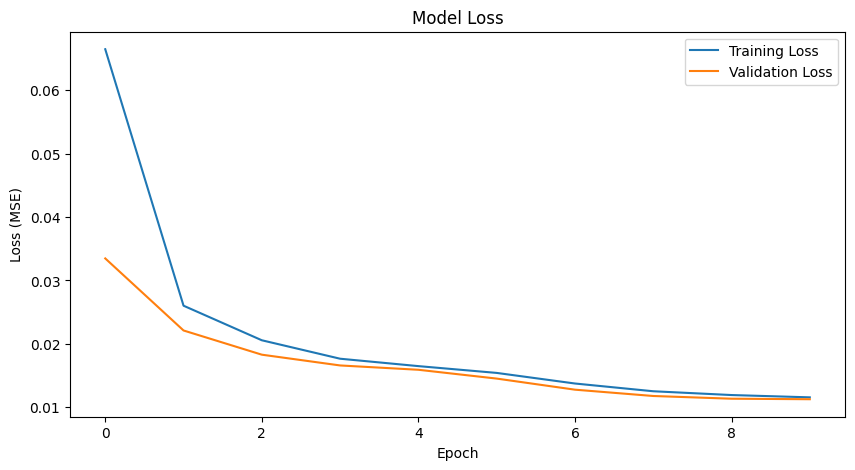

In [8]:
# Plot training and validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

## 4. Evaluation & Output

28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step


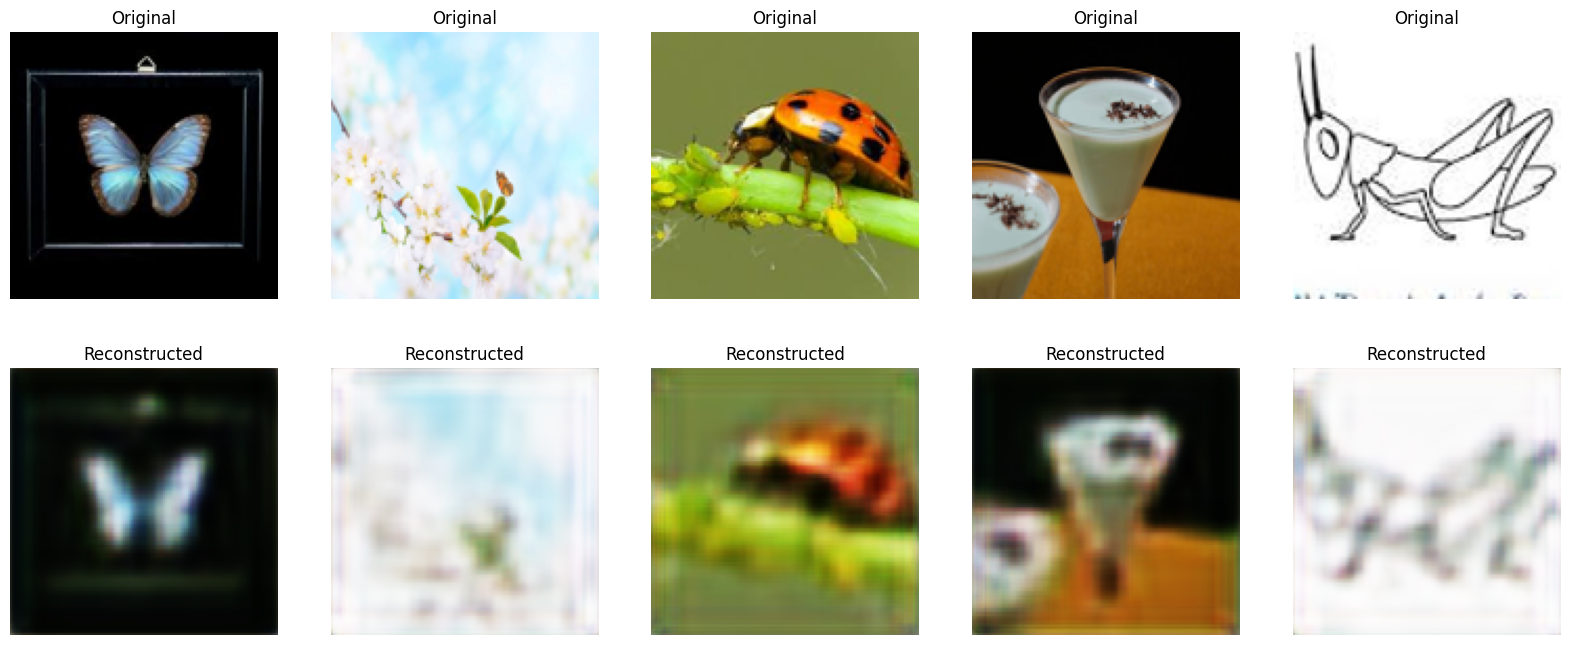

In [9]:
decoded_imgs = autoencoder.predict(X_test)

n = 5  # Number of images to display
plt.figure(figsize=(20, 8))
for i in range(n):
    # Display original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i])
    plt.title("Original")
    plt.axis("off")

    # Display reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstructed")
    plt.axis("off")
plt.show()

### Insights
- **Reconstruction Quality**: The model should be able to reconstruct the general shapes and colors of the insects. Fine details might be lost due to the compression.
- **Compression**: The input image (128x128x3) is compressed to a latent representation of (16x16x8) in the bottleneck layer, which is a significant reduction in dimensionality.
- **Loss**: The MSE loss indicates how close the reconstructed image is to the original. A lower loss means better reconstruction.